![image.png](https://i.imgur.com/a3uAqnb.png)

# **📌 Custom Dataset Class & Image Augmentations**
---

## **Working with Ready-to-Use Datasets**
So far, we've worked with **ready-to-use datasets** like:
```python
from torchvision.datasets import MNIST, CIFAR10
train_dataset = MNIST(root="./data", train=True, transform=transforms.ToTensor(), download=True)
```
These datasets are predefined in PyTorch, and we don't need to worry about loading images manually.

## **What If We Have Raw Images in a Folder?**
What if we have:
-  Images inside a folder?
-  Raw images without predefined labels?
-  Custom datasets collected manually?

How do we load and prepare them for a PyTorch model?

#### Let's start with this dataset. It is about Flowers Recognition:

In [1]:
# Please uncomment this out when you are running this lab on google colab!
import os

# Set KaggleHub cache to a directory inside /content/
os.environ["KAGGLEHUB_CACHE"] = "/content/data"

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flowers-recognition' dataset.
Path to dataset files: /kaggle/input/flowers-recognition


## **1️⃣ First Step: How to Read an Image?**
Before working with a dataset, we need to know how to **read a single image**.

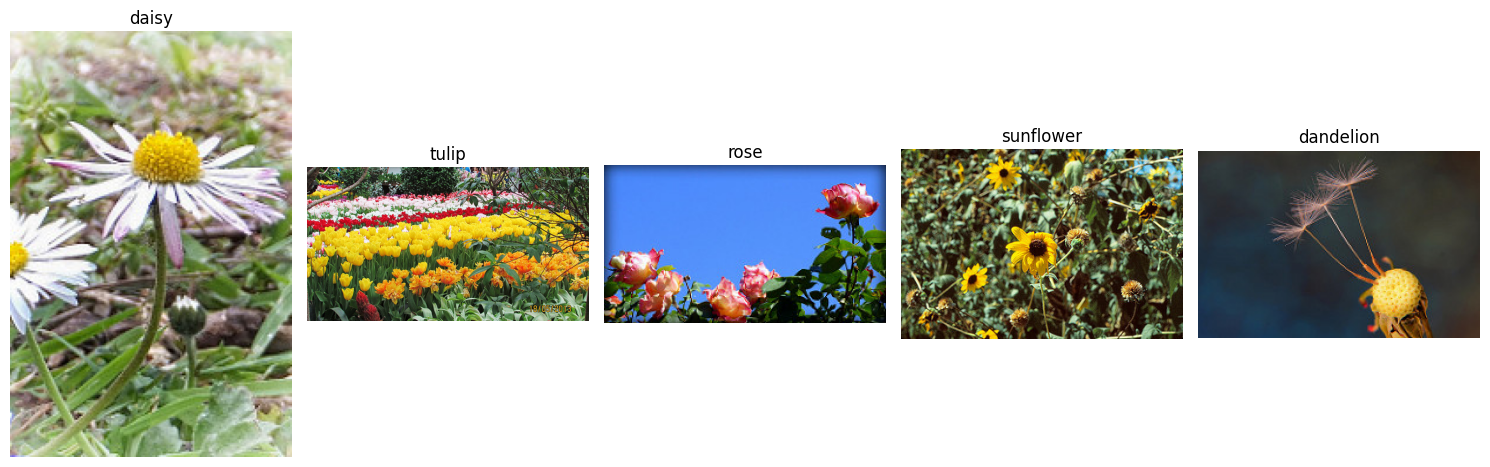

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

flowers_path = os.path.join(path, "flowers")

classes = ["daisy", "tulip", "rose", "sunflower", "dandelion"]

plt.figure(figsize=(15,5))

for i, flower_class in enumerate(classes):

    class_path = os.path.join(flowers_path, flower_class)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.title(flower_class)
    plt.axis("off")

plt.tight_layout()
plt.show()

## **2️⃣ Second Step: Finding Paths of All Images in a Folder**
To load an entire dataset, we need a **list of all image paths** inside a folder.

This could be achieved by glob.

In [4]:
import glob
folder_path = os.path.join(path, "flowers", "daisy", "*.jpg")

# Get paths of all .jpg images
image_files = glob.glob(folder_path)
print(image_files[:5])

['/kaggle/input/flowers-recognition/flowers/daisy/34670512115_af22cce24d_n.jpg', '/kaggle/input/flowers-recognition/flowers/daisy/8882282142_9be2524d38_m.jpg', '/kaggle/input/flowers-recognition/flowers/daisy/19280272025_57de24e940_m.jpg', '/kaggle/input/flowers-recognition/flowers/daisy/5133243796_44de429de5_m.jpg', '/kaggle/input/flowers-recognition/flowers/daisy/34695914906_961f92ffcd_n.jpg']


✅ **Now we have the full path for each image!**

## **📌 Do All Images Have the Same Shape?**
Before passing images to a model, we must ensure:
- **All images have the same size** (Height and Width)
- **No missing channels** (e.g., grayscale vs. RGB)

In [5]:
# Check shape of multiple images
for image_path in image_files[:5]:  # Check first 5 images
    img = Image.open(image_path)
    print(f"Image: {image_path}, Shape: {img.size}")  # Prints (Width, Height)

Image: /kaggle/input/flowers-recognition/flowers/daisy/34670512115_af22cce24d_n.jpg, Shape: (159, 240)
Image: /kaggle/input/flowers-recognition/flowers/daisy/8882282142_9be2524d38_m.jpg, Shape: (160, 240)
Image: /kaggle/input/flowers-recognition/flowers/daisy/19280272025_57de24e940_m.jpg, Shape: (240, 240)
Image: /kaggle/input/flowers-recognition/flowers/daisy/5133243796_44de429de5_m.jpg, Shape: (180, 240)
Image: /kaggle/input/flowers-recognition/flowers/daisy/34695914906_961f92ffcd_n.jpg, Shape: (240, 192)


## **📌 Why Do We Need Image Transformations?**
Ok, we can see now that we have to **resize all the images into the same size**.  
Otherwise, models wouldn't work because **they expect fixed input dimensions**.

But resizing is not the only operation we could do!  
We could also:
- **Convert an image to grayscale** 📷  
- **Crop the image** ✂️  
- **Rotate the image** 🔄  
- **Apply brightness adjustments** 💡  
- **Add noise for robustness** 🎭
- For others: https://pytorch.org/vision/0.10/transforms.html

PyTorch provides `torchvision.transforms` to easily apply these transformations.

These transformations, when applied on training data, are often called: **Augmentations**.

Augmentations are **image transformations** applied to:

✅ Improve **generalization** (prevent overfitting).  
✅ Increase **data variability** (expand dataset artificially).  
✅ Improve **robustness** (make the model handle different conditions).


Let's firstly try to resize the images we have above and convert them to grayscale.

In [6]:
from torchvision import transforms

# Define transformation
transform = transforms.Compose([
    transforms.Grayscale(),       # Make all the images gray scale
    transforms.Resize((64, 64)),  # Resize all images to 64x64
    transforms.ToTensor()
])

# Load and convert image
for i in range(10):
    image = Image.open(image_files[i])
    image_tensor = transform(image)

    # Show tensor shape
    print(image_tensor.shape)  # (Channels, Height, Width)

torch.Size([1, 64, 64])
torch.Size([1, 64, 64])
torch.Size([1, 64, 64])
torch.Size([1, 64, 64])
torch.Size([1, 64, 64])
torch.Size([1, 64, 64])
torch.Size([1, 64, 64])
torch.Size([1, 64, 64])
torch.Size([1, 64, 64])
torch.Size([1, 64, 64])


✅ **Now, our images are consistent!**

# **📌 Let's Work with the Full Dataset**
Now, let's apply what we've learned to the **full dataset**.

Given you are working with torch, you can make a code for only **One Sample** and it should work for the whole dataset. So let's do that!

---

## **1️⃣ Understanding the Dataset Structure**
We have a **flower classification dataset** stored in the following structure:

```
flowers-recognition/
│── flowers/
│   │── daisy/
│   │── dandelion/
│   │── rose/
│   │── sunflower/
│   │── tulip/
```
Each folder contains images of the respective flower type.

---

## **2️⃣ Assigning Labels to Classes**
We have **5 categories**, so we assign **numerical labels** to them:

| Flower Name   | Label |
|--------------|-------|
| Daisy        | `0`   |
| Dandelion    | `1`   |
| Rose         | `2`   |
| Sunflower    | `3`   |
| Tulip        | `4`   |

#### ✅ **Our goal**: Read each image, apply transformations, and return both the **image** and its **corresponding label**.

---

# **📌 Image Processing to a Dataset Class**
We should convert images from a raw format into a **model-ready tensor** with a label.

✅ But we don’t want to do this manually for every image.  
✅ Instead, we should **automate** this process inside `__getitem__()` in a **Dataset Class**.


---

# **📌 Let's See How a Dataset Class Looks**
A PyTorch Dataset class typically consists of **three main functions**:

| Function       | Purpose |
|---------------|------------------------------------------------|
| `__init__()`  | Loads all image paths & stores class labels. |
| `__len__()`   | Returns the total number of images. |
| `__getitem__()` | Loads, processes, and returns one image & label. |


#### Essentially, what we wrote earlier **should now go inside `__getitem__()`!**  

In [ ]:
### **🔹 General Structure of a Dataset Class**
from torch.utils.data import Dataset
from PIL import Image
import glob

class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir  # Dataset path
        self.transform = transform  # Transformations
        self.class_labels = {"daisy": 0, "dandelion": 1, "rose": 2, "sunflower": 3, "tulip": 4}

        # Get all image paths
        self.image_paths = []
        self.labels = []
        for class_name, label in self.class_labels.items():
            class_images = glob.glob(f"{root_dir}/{class_name}/*.jpg")  # Find all images
            self.image_paths.extend(class_images)
            self.labels.extend([label] * len(class_images))  # Assign labels

    def __len__(self):
        return len(self.image_paths)  # Total number of images

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]  # Get image path
        label = self.labels[idx]  # Get label

        # Load image using PIL
        image = Image.open(image_path)

        # Apply transformations (if any)
        if self.transform:
            image = self.transform(image)

        return image, label  # Return processed image & label

In [ ]:
from torchvision import transforms

# Define transformations
transform = transforms.Compose([
    transforms.Grayscale(),  # Grayscale
    transforms.Resize((64, 64)),  # Resize all images to 64x64
    transforms.ToTensor(),  # Convert image to tensor
])

# Initialize it
dataset = CustomDataset(root_dir=os.path.join(path, "flowers") ,
                       transform=transform)

#### ✅ Now, **every time we call `dataset[idx]`, it will return an image & label, processed automatically!**  

---

# **📌 But Wait... This Reads One Image at a Time!**
Right now, our **Dataset Class** loads **one image at a time** when we call:
```python
image, label = dataset[0]  # Loads only one image
```
✅ **That’s great for understanding**, but when training a model, we need to process **multiple images at once** for efficiency.

❌ **Problem**: We need batches, not single images.  
✅ **Solution**: We use `DataLoader` to handle batching automatically.

# **📌 Introducing `DataLoader`**
A **DataLoader** helps in:
- **Batching**: Groups multiple samples together for faster processing.
- **Shuffling**: Randomizes data order to improve training.
- **Multi-threading**: Loads data efficiently in parallel.

| **Argument**     | **Description** |
|-----------------|---------------|
| `dataset` | The dataset object (e.g., `train_dataset`) |
| `batch_size` | Number of samples per batch (e.g., `32`) |
| `shuffle` | Whether to **randomly shuffle** data each epoch (`True` = better for training) |
| `num_workers` | Number of parallel **CPU workers** to load data faster |
| `collate_fn` | A function to **customize how data is stacked** (useful when data has variable sizes) |


![image.png](https://i.imgur.com/aHE3lnE.png)

In [ ]:
from torch.utils.data import DataLoader

# Define batch size
batch_size = 32

# Create DataLoader
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Get a batch of training images
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Labels: {labels}")

Batch shape: torch.Size([32, 1, 64, 64]), Labels: tensor([4, 3, 4, 0, 0, 2, 4, 4, 4, 4, 4, 4, 4, 1, 3, 3, 4, 3, 4, 1, 1, 0, 4, 0,
        2, 3, 2, 0, 3, 4, 3, 4])


#### ✅ **Now, instead of reading one image at a time, we process an entire batch! This can be now fed into a model.**

### Contributed by: Mohamed Eltayeb

![image.png](https://i.imgur.com/a3uAqnb.png)